
# Modelos de Séries Temporais — ETS (Error, Trend, Season)

Este notebook reproduz, em Python, a rotina em R para modelagem ETS aplicada a dados de consumo de energia.



## 1. Pacotes necessários


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox



## 2. Carregamento dos dados


In [ ]:
# O Modelo ETS eh:
# E (Error) T (Trend) S (Season)
# O erro pode ser: aditivo (A) ou multiplicativo (M)
# A tendencia pode ser: nenhuma (N), aditiva (A),
#                       multiplicativa (M) ou 
#                       dumped (A ou M)
# A sazonalidade pode ser: nenhuma (N), aditiva (A)
#                          ou multiplicativa (M)

# Dumped = Amortecida ou suavizada

# Vamos utilizar a base de dados de consumo de energia
# eletrica na regiao sudeste (dados disponiveis no 
# IPEADATA)

# Vamos carregar o dataset e guardar em um objeto
# chamado "energia"

In [ ]:
df = pd.read_excel("energia.xlsx")

# Vamos utilizar apenas a coluna 2, que contem os dados de consumo de energia
# Selecionando a segunda coluna
energia = df.iloc[:,1]

In [ ]:
# Construindo um objeto do tipo ts (time series)
# Criando índice temporal
dates = pd.date_range(start="1979-01-01", periods=len(energia), freq="MS")
energia = pd.Series(energia.values, index=dates)

energia.head()


1979-01-01    5623
1979-02-01    5551
1979-03-01    5725
1979-04-01    5797
1979-05-01    6002
Freq: MS, dtype: int64

In [12]:
# Vamos ver o tamanho da amostra
print(len(energia))

513



## 3. Separação treino e teste


492 21


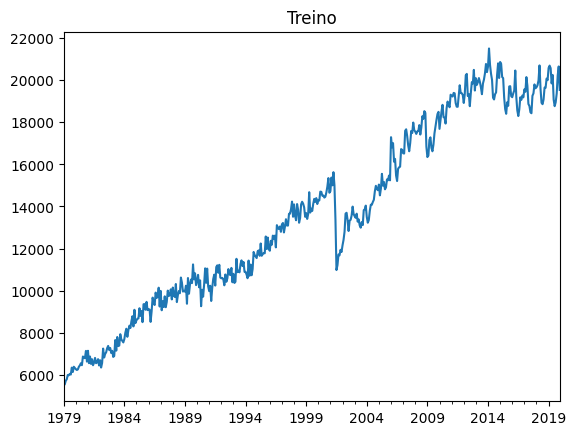

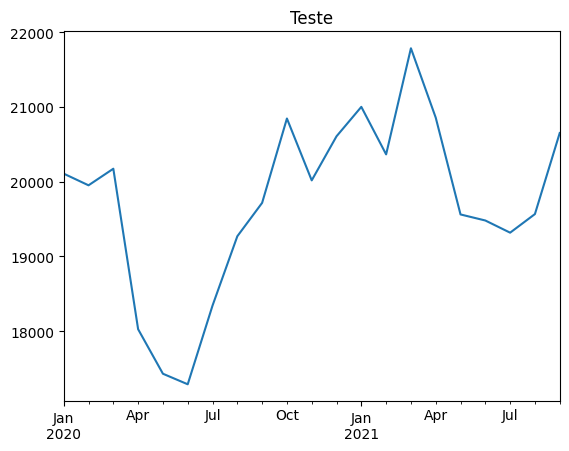

In [ ]:
# Vamos dividir o dataset, uma parte para treinamento do modelo e outra para teste

treino = energia[:'2019-12']
teste = energia['2020-01':]

print(len(treino), len(teste))

treino.plot(title="Treino")
plt.show()

teste.plot(title="Teste")
plt.show()



## 4. Estimação do modelo ETS

O modelo ETS considera:
- Erro (E): aditivo ou multiplicativo
- Tendência (T)
- Sazonalidade (S)


In [ ]:
# Vamos estimar o modelo ETS e guardar em um objeto
# chamado "energiatreino"

# Em Python os hyperparametros são definidos manualmente, diferentemente da função ets() do R que faz essa busca
# automática

modelo = ETSModel(treino, error='mul', trend='add', seasonal='mul', seasonal_periods=12)
energiatreino = modelo.fit()

print(energiatreino.summary())


                                 ETS Results                                  
Dep. Variable:                      y   No. Observations:                  492
Model:                       ETS(MAM)   Log Likelihood               -3636.800
Date:                Tue, 07 Apr 2026   AIC                           7309.599
Time:                        20:04:38   BIC                           7385.172
Sample:                    01-01-1979   HQIC                          7339.274
                         - 12-01-2019   Scale                            0.001
Covariance Type:               approx                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
smoothing_level         0.6367      0.042     15.020      0.000       0.554       0.720
smoothing_trend         0.0005      0.005      0.095      0.925      -0.010       0.011
smoothing_season

In [ ]:
# Esses hypeparametros foi definidos manualmente
# o "erro eh multiplicativo",
# a "tendencia eh aditiva" e a "sazonalidade eh multiplicativa"
# Ao final vamos analisar as estatisticas de erro.

In [20]:
import itertools
import pandas as pd
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

def auto_ets(y, seasonal_periods=12, criterion="aicc"):
    
    error_opts = ["add", "mul"]
    trend_opts = [None, "add"]
    seasonal_opts = [None, "add", "mul"]
    damped_opts = [True, False]

    results = []

    for error, trend, seasonal, damped in itertools.product(
        error_opts, trend_opts, seasonal_opts, damped_opts
    ):
        # Regras de consistência (como no R)
        if trend is None and damped:
            continue
        if seasonal is not None and seasonal_periods is None:
            continue

        try:
            model = ETSModel(
                y,
                error=error,
                trend=trend,
                seasonal=seasonal,
                damped_trend=damped if trend else False,
                seasonal_periods=seasonal_periods
            )

            fit = model.fit(disp=False)

            # Critério de seleção
            if criterion == "aic":
                score = fit.aic
            elif criterion == "bic":
                score = fit.bic
            else:  # AICc (aproximação)
                n = len(y)
                k = fit.params.size
                aic = fit.aic
                score = aic + (2*k*(k+1))/(n-k-1)

            results.append({
                "model": (error, trend, seasonal, damped),
                "fit": fit,
                "score": score
            })

        except:
            continue

    # Seleciona o melhor modelo
    best = min(results, key=lambda x: x["score"])

    print("Melhor modelo:", best["model"])
    print("Score:", best["score"])

    return best

In [21]:
best_model = auto_ets(treino, seasonal_periods=12)

fit = best_model["fit"]
forecast = fit.forecast(steps=12)

Melhor modelo: ('add', None, 'mul', False)
Score: 7303.676553203347



## 5. Previsão


In [ ]:
# Vamos fazer uma previsao para os 21 periodos de tempo
# do dataset e depois comparar com os dados reais

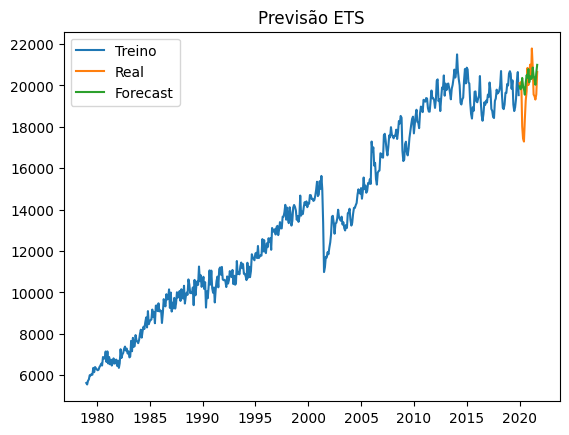

In [14]:

h = len(teste)
forecast = energiatreino.forecast(steps=h)

plt.figure()
plt.plot(treino, label="Treino")
plt.plot(teste, label="Real")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("Previsão ETS")
plt.show()



## 6. Avaliação de acurácia


In [6]:

mae = np.mean(np.abs(forecast - teste))
rmse = np.sqrt(np.mean((forecast - teste)**2))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 879.1139604251574
RMSE: 1154.267672034545



## 7. Análise de resíduos


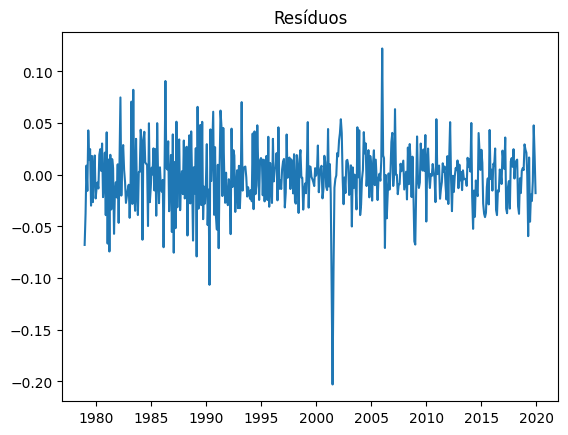

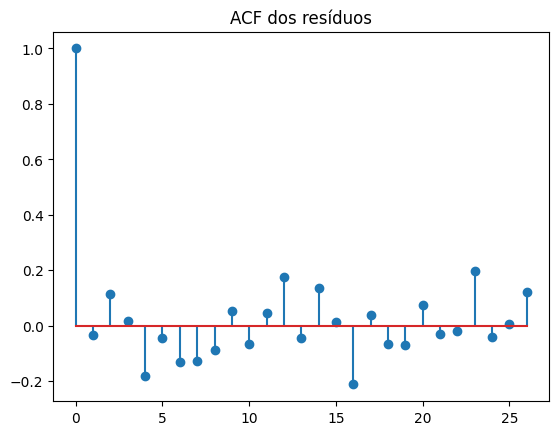

In [15]:

residuos = energiatreino.resid

plt.plot(residuos)
plt.title("Resíduos")
plt.show()

acf_vals = acf(residuos)
plt.stem(acf_vals)
plt.title("ACF dos resíduos")
plt.show()



## 8. Teste de Ljung-Box

Hipóteses:
- H0: resíduos são independentes
- H1: resíduos são correlacionados


In [ ]:
# Vamos fazer a validacao do modelo
# Vamos analisar os residuos (erros) das predicoes
# As condicoes sao:
# a) os residuos nao podem ser correlacionados; se eles
#    sao correlacionados eles contem informacoes nos 
#    que deveriam estar no modelo;
# b) os residuos devem ter media zero, se nao, entao as
#    predicoes sao viesadas

# Vamos aplicar o teste de Ljung-Box com um lag (conforme 
# identificamos anteriormente)

In [ ]:
# As hipoteses do teste Ljung-box são:
# H0: Os residuos são iid - independentes e identicamente 
#     distribuidos (o modelo nao possui erros de 
#     especificacao)
# HA: Os residuos não são iid - independentes e 
#     identicamente distribuidos (o modelo possui erros de
#     especificacao)

In [8]:

lb_test = acorr_ljungbox(residuos, lags=[1], return_df=True)
print(lb_test)


    lb_stat  lb_pvalue
1  0.576058   0.447861


In [ ]:
# A estatistica de teste eh uma distribuicao chi-squared
# Obtendo os valores criticos (da tabela) para 95% de 
# confianca

In [11]:
from scipy.stats import chi2

valor_critico = chi2.ppf(0.95, df=1)
print(valor_critico)

3.841458820694124


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

def pchisq_gc(x, df=1, region="above", graph=True):
    x = np.array(x)

    if region == "above":
        prob = 1 - chi2.cdf(x, df)
    elif region == "below":
        prob = chi2.cdf(x, df)
    else:
        raise ValueError("region deve ser 'above' ou 'below'")

    print("Probabilidade:", prob)

    if graph:
        xx = np.linspace(0, max(10, x.max()*2), 500)
        yy = chi2.pdf(xx, df)

        plt.plot(xx, yy)
        
        if region == "above":
            mask = xx >= x[0]
        else:
            mask = xx <= x[0]

        plt.fill_between(xx[mask], yy[mask], color='blue', alpha=0.3)
        plt.axvline(x[0], color='r')
        plt.title(f"Qui-quadrado (df={df})")
        plt.show()

    return prob

Probabilidade: [0.04999999]


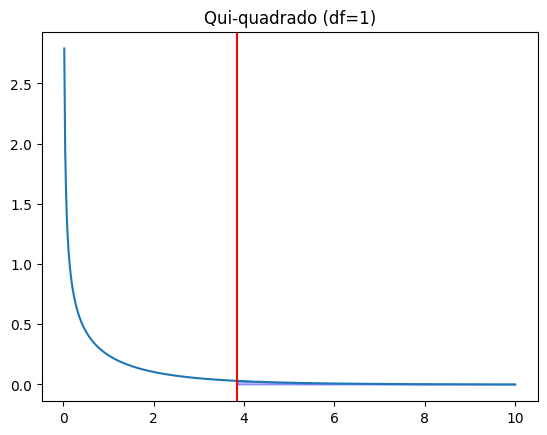

array([0.04999999])

In [ ]:
# Construindo o grafico para destacar os 5% do lado 
# superior da distribuicao

pchisq_gc([3.841459], df=1, region="above", graph=True)

In [ ]:
# Como a estatistica de Ljung-Box eh menor que o valor 
# tabelado nao rejeitamos H0.

# Nos nao queremos rejeitar H0 (nos desejamos um 
# p-value>0.05), como o p-value eh 0.447861 nao rejeitamos
# H0. O modelo nao possui erros de especificacao